# Computer Vision — Session 2 Lab: Pretrained Models & Transfer Learning
### ITI · Instructor: Ahmed Abdelsalam

Today you'll use models trained on millions of images, then adapt one to a brand-new task.

**Rules of the lab**
- Made for **Google Colab**. For Exercise 3 (training), a GPU runtime is faster: *Runtime → Change runtime type → GPU*.
- Try first, ask second.
- Done early? Head to the **Challenges**.

## Setup — run this first

In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from skimage import data

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights).eval()
preprocess = weights.transforms()
categories = weights.meta["categories"]
print("Pretrained ResNet-18 ready.")

Using: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 107MB/s]


Pretrained ResNet-18 ready.


## Exercise 1 — Classify real images

Write a function `classify(pil_image, k=5)` that:
1. Preprocesses the image and adds a batch dimension.
2. Runs the model (no gradients).
3. Prints the **top-k** class names with their probabilities.

Then test it on `data.chelsea()` (cat) and `data.coffee()` (coffee cup).

In [2]:
# Your code here
def classify(pil_image, k=5):
    x = preprocess(pil_image).unsqueeze(0)

    with torch.no_grad():
        logits = model(x)
    probs = torch.softmax(logits, dim=1)
    topk = torch.topk(probs, k)

    print(f"Top-{k} predictions:")
    for score, idx in zip(topk.values[0], topk.indices[0]):
        print(f"{categories[idx]:20s} {score.item()*100:.2f}%")


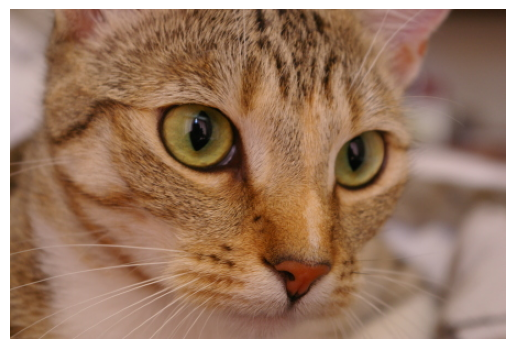

Top-5 predictions:
Egyptian cat         39.14%
tiger cat            38.61%
tabby                21.76%
lynx                 0.45%
Persian cat          0.02%


In [3]:
cat = Image.fromarray(data.chelsea())
plt.imshow(cat)
plt.axis("off")
plt.show()

classify(cat)

## Exercise 2 — Fix the broken preprocessing

Below is a **broken** preprocessing pipeline: it resizes to the wrong size and forgets to normalize. It makes the model confidently *wrong*.

**Your job:** replace `broken_preprocess` with the model's correct transforms (`weights.transforms()`), and show the top prediction goes from wrong to right on the cat image.

In [4]:
# Your code here
correct_preprocess = weights.transforms()
cat = Image.fromarray(data.chelsea())
x = correct_preprocess(cat).unsqueeze(0)

with torch.no_grad():
    logits = model(x)
probs = torch.softmax(logits, dim=1)
top5 = torch.topk(probs,5)

for score, idx in zip(top5.values[0], top5.indices[0]):
    print(f"{categories[idx]:20s} {score.item()*100:.2f}%")

Egyptian cat         39.14%
tiger cat            38.61%
tabby                21.76%
lynx                 0.45%
Persian cat          0.02%


## Exercise 3 — Transfer learning: ants vs bees 🐜🐝

The main event. We'll adapt the pretrained ResNet to a task it has never seen: telling ants from bees, using only a few hundred images.

**Step 1 — download the dataset** (run as given):

In [5]:
import urllib.request, zipfile, os

if not os.path.exists("hymenoptera_data"):
    url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
    urllib.request.urlretrieve(url, "hym.zip")
    with zipfile.ZipFile("hym.zip") as z:
        z.extractall(".")
print("Dataset ready:", os.listdir("hymenoptera_data/train"))

Dataset ready: ['bees', 'ants']


**Step 2 — load the images** with the model's transforms (run as given). `ImageFolder` automatically labels images by their folder name.

Classes: ['ants', 'bees']
Train images: 244 | Val images: 153


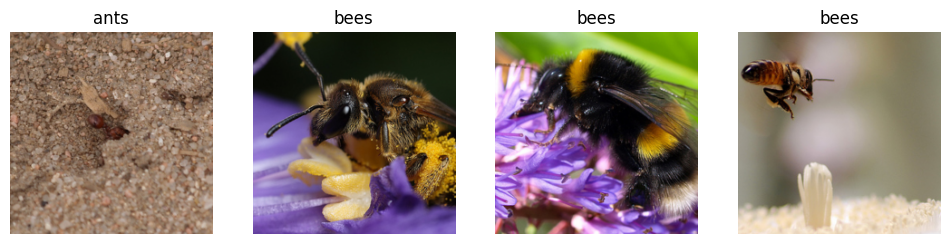

In [6]:
from torchvision import datasets
from torch.utils.data import DataLoader

train_ds = datasets.ImageFolder("hymenoptera_data/train", transform=preprocess)
val_ds   = datasets.ImageFolder("hymenoptera_data/val",   transform=preprocess)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=16)

print("Classes:", train_ds.classes)          # ['ants', 'bees']
print("Train images:", len(train_ds), "| Val images:", len(val_ds))

imgs, labels = next(iter(train_loader))
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    pic = imgs[i].permute(1, 2, 0).numpy()
    pic = (pic * [0.229,0.224,0.225] + [0.485,0.456,0.406]).clip(0, 1)
    ax[i].imshow(pic); ax[i].set_title(train_ds.classes[labels[i]]); ax[i].axis("off")
plt.show()

**Step 3 — build the transfer-learning model.** Fill in the three steps: load pretrained, **freeze** all parameters, and **replace** the final `fc` layer with a new `nn.Linear` that outputs **2** classes.

In [7]:
# Your code here
weights = ResNet18_Weights.DEFAULT
tl_model = models.resnet18(weights=weights)

for param in tl_model.parameters():
    param.requires_grad = False

tl_model.fc = nn.Linear(tl_model.fc.in_features,2)
device = "cuda" if torch.cuda.is_available() else "cpu"
tl_model = tl_model.to(device)

**Step 4 — train the new head** for 3 epochs and print validation accuracy each epoch. Fill in the training loop (zero grad, forward, loss, backward, step) — only the new head learns.

In [8]:
# Your code here
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tl_model.fc.parameters(), lr=0.001)

for epoch in range(3):
    tl_model.train()
    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = tl_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    tl_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = tl_model(images)
            predicted = outputs.argmax(dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    print(f"Epoch {epoch+1}: Accuracy = {100*correct/total:.2f}%")

Epoch 1: Accuracy = 83.01%
Epoch 2: Accuracy = 90.85%
Epoch 3: Accuracy = 89.54%


**Step 5 — reflect.** In a text cell, answer: roughly how many images did we train on, and how many epochs? Compare that to the millions of images / days it took to train the original model. What did transfer learning save us?

## 🎯 Bonus demo — object detection (run as given)

Classification says *what*. **Detection** says *what AND where*. Here's a pretrained detector finding and boxing objects — no training needed. (First run downloads weights; inference takes a few seconds on CPU.)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 125MB/s]


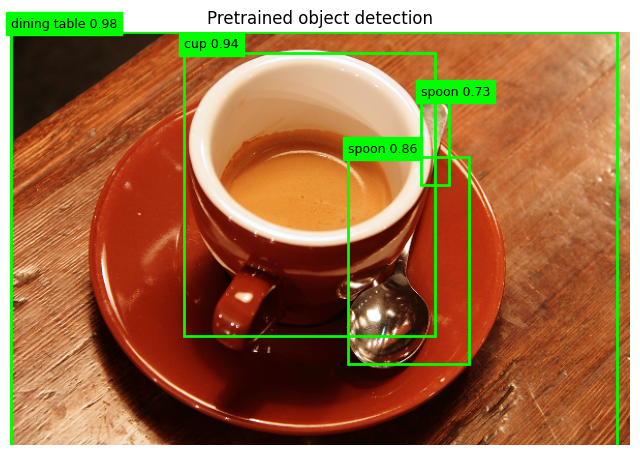

In [9]:
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights)
from torchvision.transforms.functional import to_tensor

det_weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
detector = fasterrcnn_resnet50_fpn(weights=det_weights).eval()
det_labels = det_weights.meta["categories"]

scene = data.coffee()
x = to_tensor(Image.fromarray(scene))
with torch.no_grad():
    output = detector([x])[0]

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(scene); ax.axis("off")
keep = output["scores"] > 0.7
for box, label, score in zip(output["boxes"][keep], output["labels"][keep], output["scores"][keep]):
    x1, y1, x2, y2 = box.tolist()
    ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                 fill=False, edgecolor="lime", linewidth=2))
    ax.text(x1, y1-5, f"{det_labels[label]} {score:.2f}",
            color="black", backgroundcolor="lime", fontsize=9)
plt.title("Pretrained object detection")
plt.show()

## 🚀 Challenges

Add new cells as needed.

**Challenge A — Your own image.**
Upload any photo to Colab (the folder icon on the left, or `files.upload()`), open it with `Image.open("yourfile.jpg").convert("RGB")`, and run your `classify()` function on it. Did ResNet get it right?

Saving hnu.jpg to hnu (1).jpg


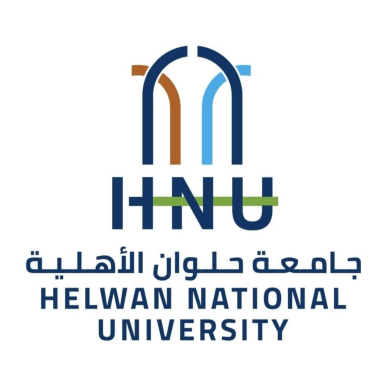

Top-5 predictions:
web site             11.94%
chime                8.71%
hook                 5.10%
folding chair        4.06%
whistle              2.92%


In [16]:
# Your code here
from google.colab import files
files.upload()
img = Image.open("hnu.jpg").convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.show()

classify(img)

**Challenge B — Predict on a validation image.**
Take one image from `val_ds`, run your trained `tl_model` on it, and show the image with the predicted class ("ants" or "bees") vs the true class in the title.

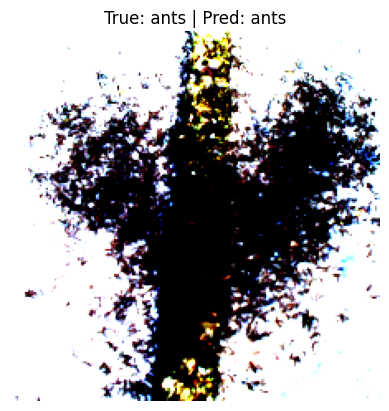

In [17]:
# Your code here
image, label = val_ds[0]
plt.imshow(image.permute(1,2,0))
plt.axis("off")
with torch.no_grad():
    output = tl_model(image.unsqueeze(0).to(device))

prediction = output.argmax(dim=1).item()
plt.title(f"True: {train_ds.classes[label]} | Pred: {train_ds.classes[prediction]}")

plt.show()

**Challenge C — Speed vs accuracy.**
Load `models.mobilenet_v3_small(weights="DEFAULT")` and classify the cat image with it. Compare its top prediction to ResNet's. (MobileNet is built for speed on phones.)

In [18]:
# Your code here
from torchvision import models
from torchvision.models import MobileNet_V3_Small_Weights
weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet = models.mobilenet_v3_small(weights=weights)
mobilenet.eval()

preprocess = weights.transforms()
x = preprocess(cat).unsqueeze(0)
with torch.no_grad():
    logits = mobilenet(x)

probs = torch.softmax(logits, dim=1)
top1 = torch.topk(probs, 1)
print("MobileNet Prediction:")

for score, idx in zip(top1.values[0], top1.indices[0]):
    print(f"{categories[idx]:20s} {score.item()*100:.2f}%")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 46.3MB/s]

MobileNet Prediction:
tiger cat            49.31%
